In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# Load the dataset (replace the file path with your actual path)
file_path = '/content/RTA Dataset.csv'
df = pd.read_csv(file_path)


In [ ]:
# Checking for missing values
df.isnull().sum()

# Fill missing values with a placeholder or a strategy of your choice
df.fillna('Unknown', inplace=True)


In [ ]:
# Label Encoding for categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


In [ ]:
# Feature Scaling for numerical features
scaler = StandardScaler()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_features] = scaler.fit_transform(df[numerical_features])


In [ ]:
# Ensure that the target variable is in categorical format
le = LabelEncoder()
y = le.fit_transform(df['Accident_severity'])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize and train the XGBoost classifier
model = XGBClassifier()
model.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8445616883116883


In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:\n{conf_matrix}")

class_report = classification_report(y_test, y_pred)
print(f"Classification Report:\n{class_report}")

Confusion Matrix:
[[   5    1   31]
 [   0   41  322]
 [   0   29 2035]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.14      0.24        37
           1       0.58      0.11      0.19       363
           2       0.85      0.99      0.91      2064

    accuracy                           0.84      2464
   macro avg       0.81      0.41      0.45      2464
weighted avg       0.81      0.84      0.80      2464



<Figure size 1000x800 with 0 Axes>

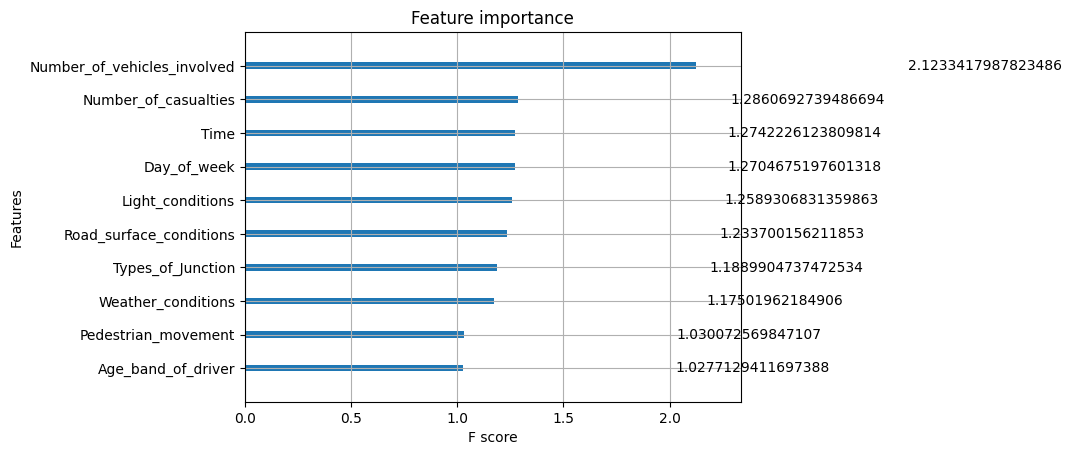

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=10, importance_type='gain')
plt.show()
